/home/tandrade/.local/lib/python3.9/site-packages/zfit/__init__.py:63: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


Status do Fit: VÁLIDO ✅
FitResult of
<ExtendedUnbinnedNLL model=[<zfit.<class 'zfit.models.functor.SumPDF'>  params=[Composed_autoparam_1, Composed_autoparam_2]] data=[<zfit.Data: Data obs=('BToTrkTrkMuMu_fit_mass_Kpi_good',) shape=(206730, 1)>] constraints=[]> 
with
<Minuit Minuit tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 0.00011 │       -110351.71 |  6461.542 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name      value  (rounded)    at limit
------  ------------------  ----------
n_sig              8256.91       False
n_bkg               198473       False
mu                 5.27394       False
sigma            0.0298597       False
alpha             0.979201   

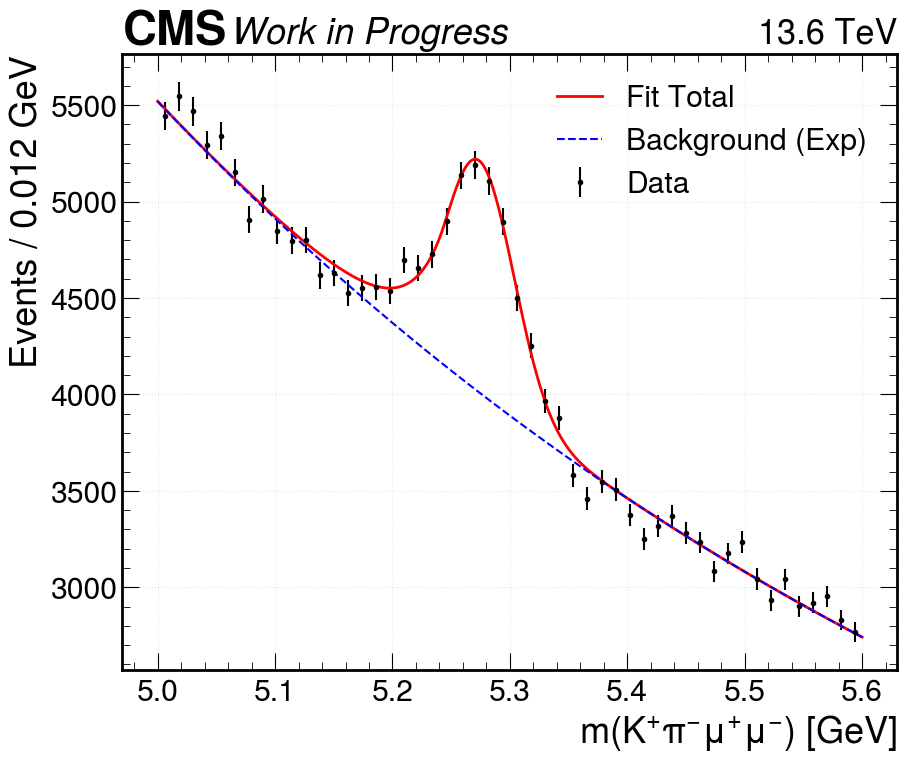

>>> Gerando plots comparativos com Ratio...
   Plotting pt (branch: BToTrkTrkMuMu_fit_pt_good)...
   Plotting eta (branch: BToTrkTrkMuMu_fit_eta_good)...
   Plotting phi (branch: BToTrkTrkMuMu_fit_phi_good)...
   Plotting svprob (branch: BToTrkTrkMuMu_svprob_good)...
   Plotting mumu_pt (branch: MuMu_pt_good)...
   Plotting mumu_eta (branch: MuMu_eta_good)...
   Plotting mumu_phi (branch: MuMu_phi_good)...
   Plotting kstar_mass (branch: BToTrkTrkMuMu_fit_ditrack_mass_Kpi_good)...
>>> Processo concluído com sucesso!


In [2]:
%run ./sPlot_Zfit_Psi2s.ipynb

In [1]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
import joblib

# Estilo CMS
plt.style.use(hep.style.CMS)

In [3]:
features_raw = [
        "BToTrkTrkMuMu_fit_l1_pt_good", "BToTrkTrkMuMu_fit_l2_pt_good",
        "BToTrkTrkMuMu_fit_trk1_pt_good", "BToTrkTrkMuMu_fit_trk2_pt_good",
        "BToTrkTrkMuMu_fit_eta_good", "BToTrkTrkMuMu_fit_cos2D_good",
        "BToTrkTrkMuMu_trk1_dca_good", "BToTrkTrkMuMu_trk1_dcaErr_good",
        "BToTrkTrkMuMu_trk2_dca_good", "BToTrkTrkMuMu_trk2_dcaErr_good"
    ]
cols_sel = ["BToTrkTrkMuMu_fit_mass_Kpi_good", "MuMu_mass_good", "HLT_DoubleMu4_3_LowMass"]

In [4]:
def load_data_clean(path):
    with uproot.open(path) as f:
        df = ak.to_dataframe(f["tree_ML"].arrays(features_raw + cols_sel, library="ak"))    
    mask = (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] > 5.0) & (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] < 5.6) & \
           (df['MuMu_mass_good'] > 3.3) & (df['MuMu_mass_good'] < 4.05) & (df['HLT_DoubleMu4_3_LowMass'] == 1)
    return df[mask].copy()

df_data_bdt = load_data_clean("/home/tandrade/Flavour_Anomalies/Data/final_data_skim.root")
df_mc_bdt = load_data_clean("/home/tandrade/Flavour_Anomalies/Data/final_mc_psi2s_skim.root")

In [5]:
df_data_bdt["sweight_sig"] = df_data_bdt["sweight_sig"].values if "sweight_sig" in df_data_bdt.columns else 1.0

In [6]:
features_final = [  
    "BToTrkTrkMuMu_fit_l1_pt_good", "BToTrkTrkMuMu_fit_l2_pt_good",
    "BToTrkTrkMuMu_fit_trk1_pt_good", "BToTrkTrkMuMu_fit_trk2_pt_good",
    "BToTrkTrkMuMu_fit_eta_good", "BToTrkTrkMuMu_fit_cos2D_good",
    "trk1_dca_sig", "trk2_dca_sig"
]

In [7]:
for df_tmp in [df_data_bdt, df_mc_bdt]:
    df_tmp['trk1_dca_sig'] = df_tmp['BToTrkTrkMuMu_trk1_dca_good'] / df_tmp['BToTrkTrkMuMu_trk1_dcaErr_good'].replace(0, np.nan)
    df_tmp['trk2_dca_sig'] = df_tmp['BToTrkTrkMuMu_trk2_dca_good'] / df_tmp['BToTrkTrkMuMu_trk2_dcaErr_good'].replace(0, np.nan)
    df_tmp.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_tmp.dropna(subset=features_final + (["sweight_sig"] if "sweight_sig" in df_tmp.columns else []), inplace=True)

In [8]:
df_data_bdt['label'], df_mc_bdt['label'] = 1, 0
df_data_bdt['weight'], df_mc_bdt['weight'] = df_data_bdt['sweight_sig'], 1.0

In [9]:
df_all = pd.concat([df_data_bdt, df_mc_bdt], ignore_index=True)

In [11]:
model = joblib.load("model_reweighting_jpsi.joblib")

In [12]:
X = df_all[features_final]

In [20]:
scores = model.predict_proba(df_all[features_final])[:, 1]

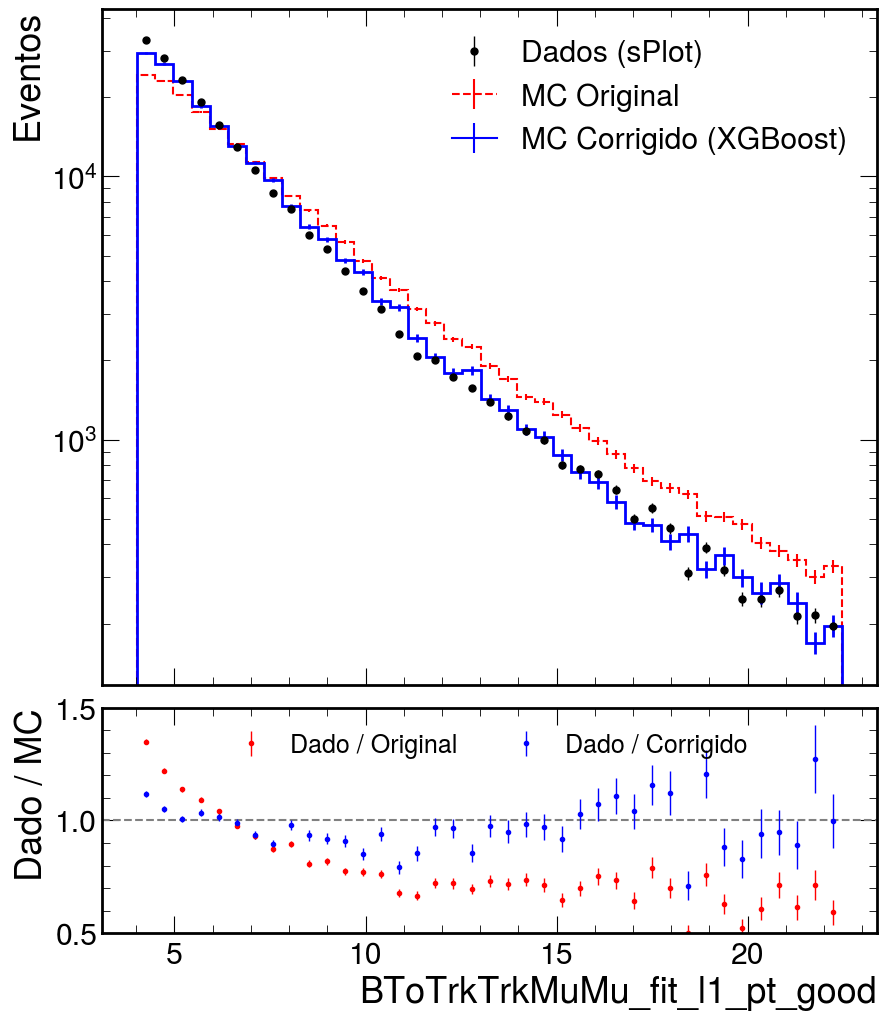

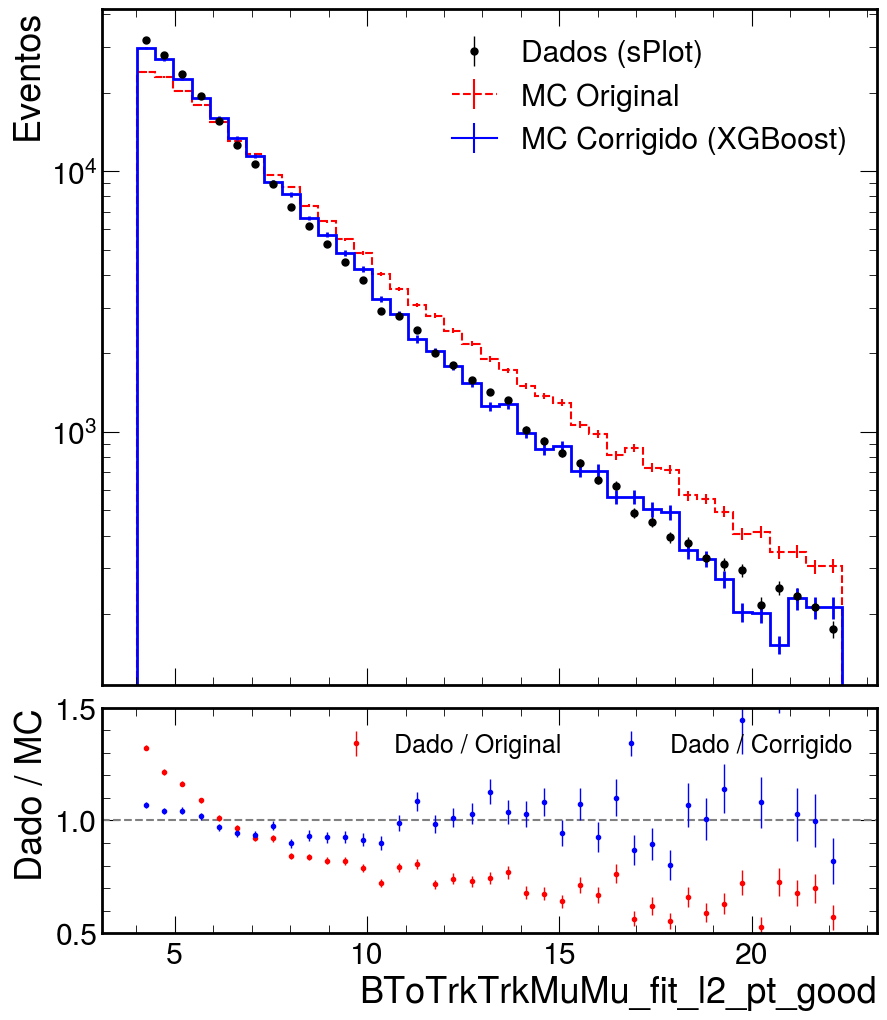

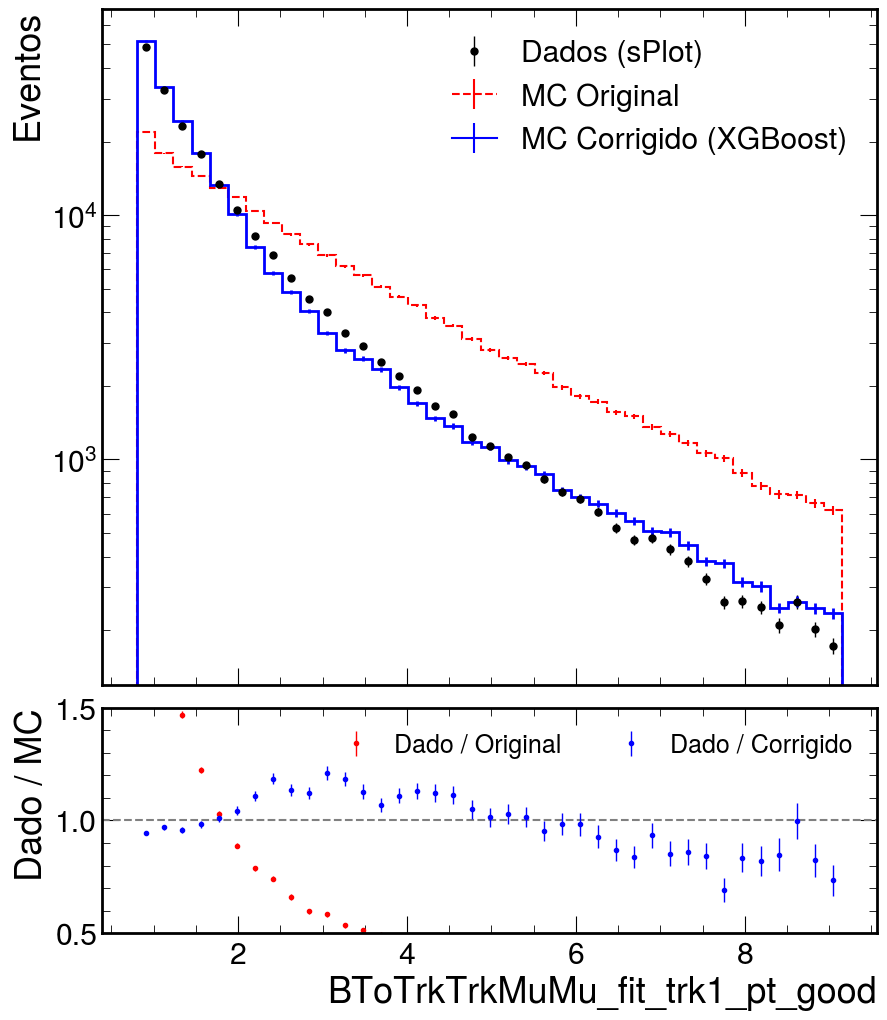

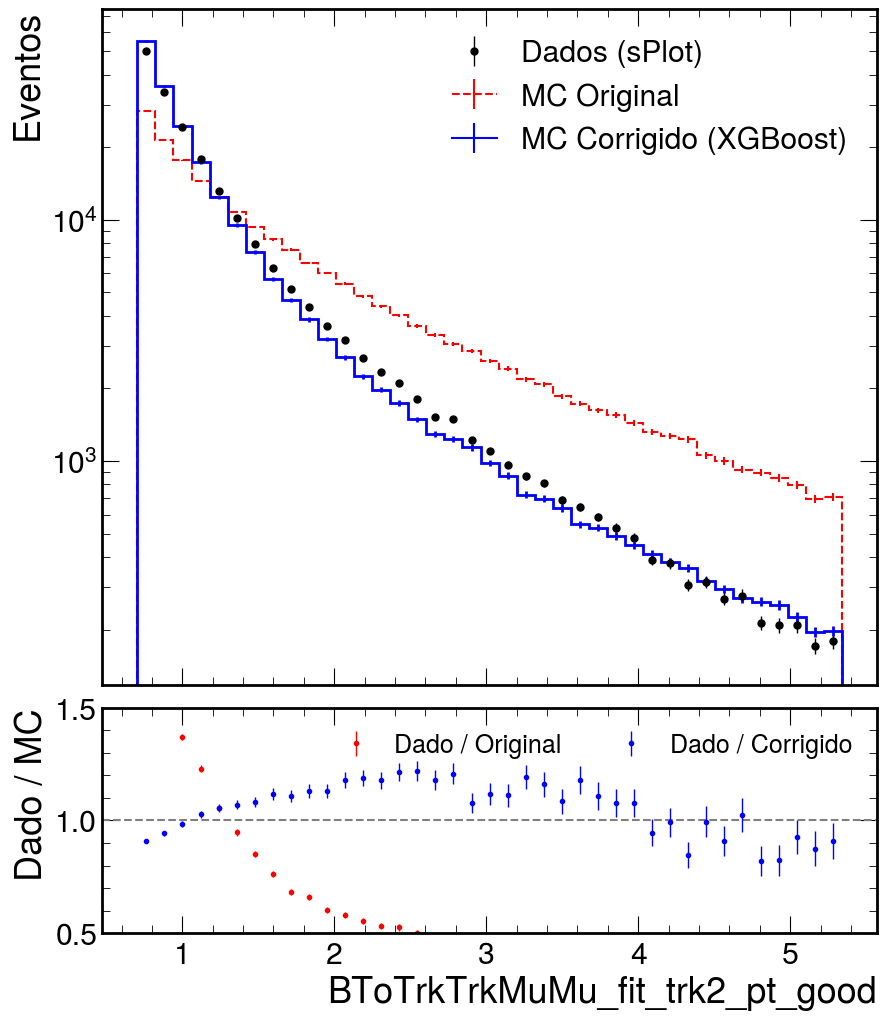

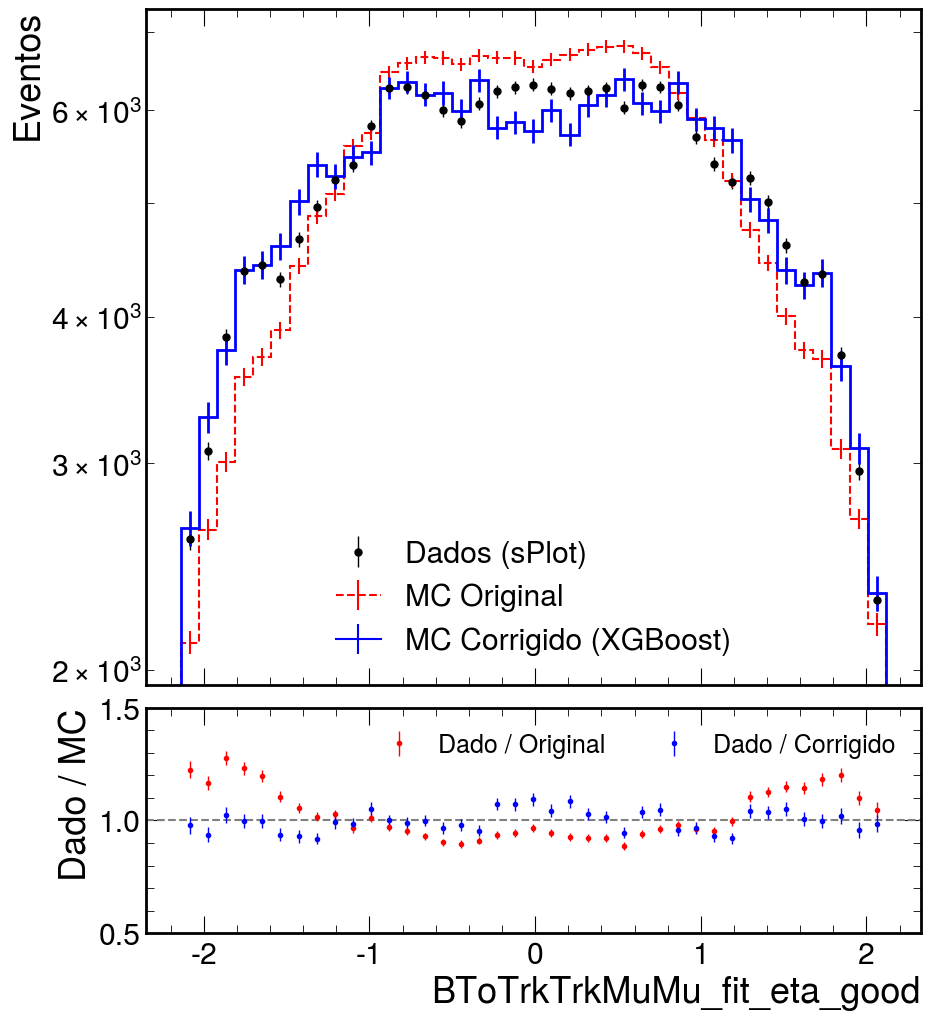

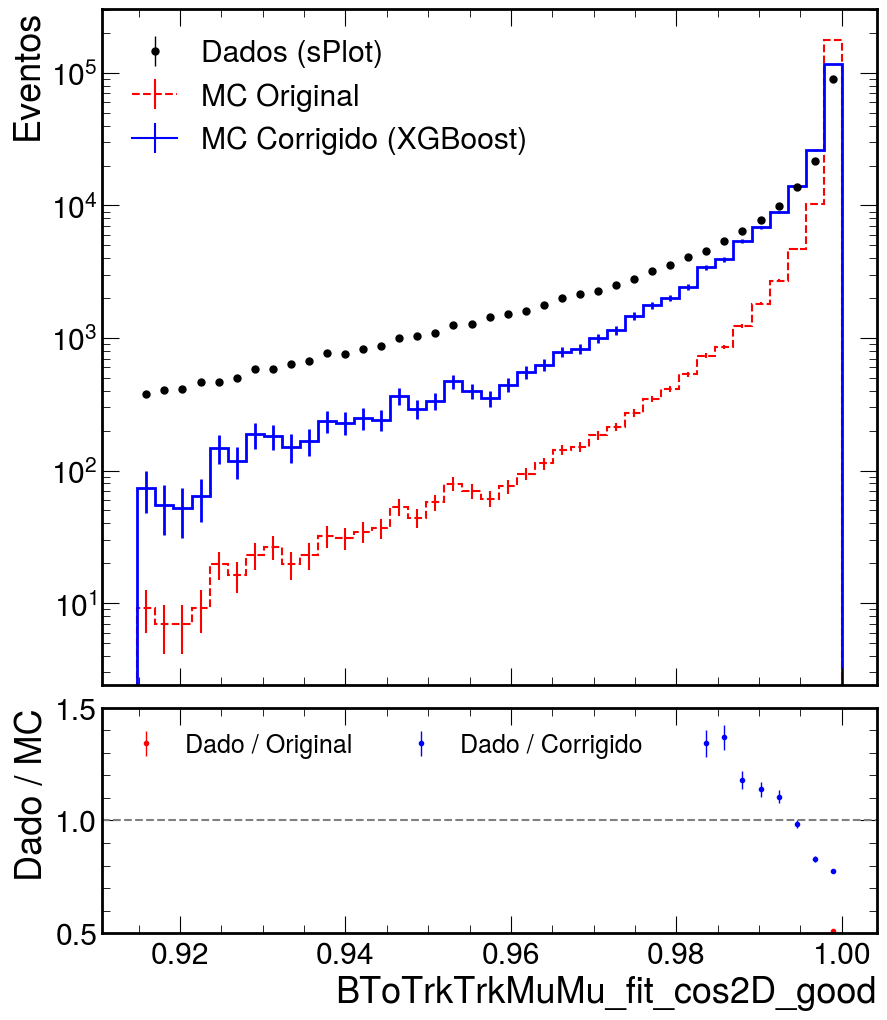

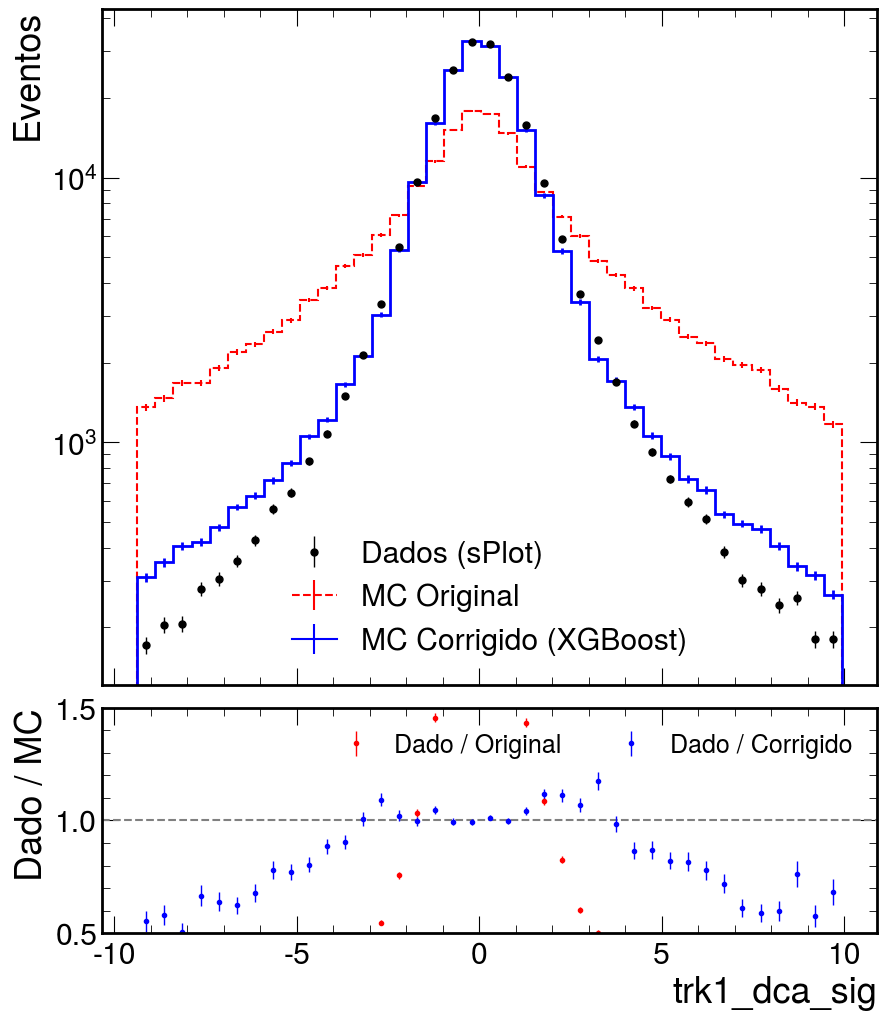

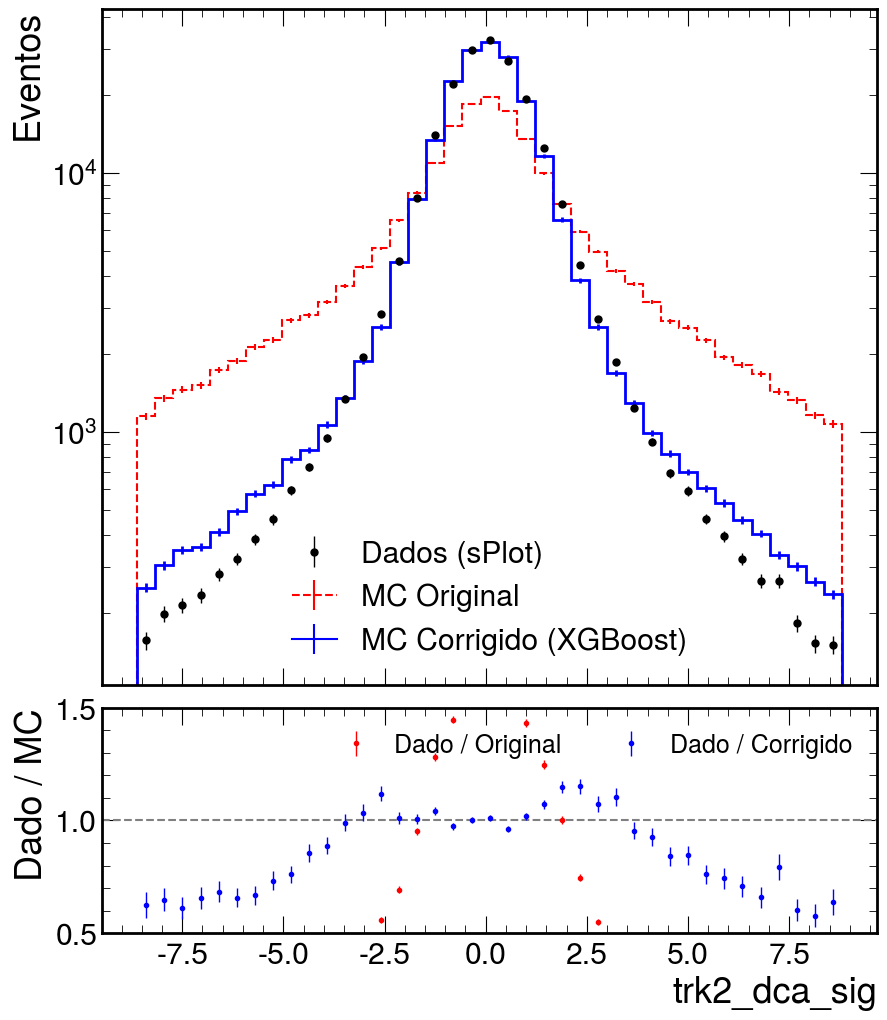

In [26]:
# ... (mantenha o código inicial igual até o cálculo do score)

# 1. Calcular scores e pesos no df_all
X = df_all[features_final]
scores = model.predict_proba(X)[:, 1]
epsilon = 1e-5
scores = np.clip(scores, epsilon, 1.0 - epsilon)

# 2. Criar a coluna 'bdt_weight' (usando o nome que sua função de plot espera)
df_all['bdt_weight'] = scores / (1 - scores)

# Normalização global dos pesos (opcional, mas recomendado)
df_all.loc[df_all['label'] == 0, 'bdt_weight'] *= (len(df_all[df_all['label'] == 0]) / df_all.loc[df_all['label'] == 0, 'bdt_weight'].sum())

# 3. IMPORTANTE: Atualizar os dataframes originais com os novos pesos
# Como df_all foi concatenado mantendo a ordem, podemos separar:
df_data_bdt = df_all[df_all['label'] == 1].copy()
df_mc_bdt = df_all[df_all['label'] == 0].copy()

# 4. Ajuste na função de plot (verificação de segurança para sPlot)
def plot_all_branches(df_data, df_mc, features):
    for var in features:
        # Define range baseado nos dados (removendo NaNs para o percentile)
        data_clean = df_data[var].dropna()
        min_v, max_v = np.percentile(data_clean, [1, 99])
        bins = np.linspace(min_v, max_v, 40)
        
        fig, (ax, rax) = plt.subplots(2, 1, figsize=(10, 12), 
                                     gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}, 
                                     sharex=True)
        
        # Pesos de sinal (sPlot) - Garante que se não existir, usa 1.0
        w_data = df_data['sweight_sig'] if 'sweight_sig' in df_data.columns else np.ones(len(df_data))
        
        # Histogramas
        h_dat, _ = np.histogram(df_data[var], bins=bins, weights=w_data)
        h_dat_err = np.sqrt(np.histogram(df_data[var], bins=bins, weights=w_data**2)[0])
        
        h_raw_v, _ = np.histogram(df_mc[var], bins=bins)
        h_raw_err = np.sqrt(h_raw_v)
        
        # Aqui o erro 'bdt_weight' foi resolvido pois atualizamos o df_mc_bdt acima
        h_cor, _ = np.histogram(df_mc[var], bins=bins, weights=df_mc['bdt_weight'])
        h_cor_err = np.sqrt(np.histogram(df_mc[var], bins=bins, weights=df_mc['bdt_weight']**2)[0])

        # Normalização para comparação de forma
        s_raw = h_dat.sum() / h_raw_v.sum() if h_raw_v.sum() > 0 else 1
        s_cor = h_dat.sum() / h_cor.sum() if h_cor.sum() > 0 else 1
        
        # Plot Superior
        hep.histplot(h_dat, bins=bins, yerr=h_dat_err, label='Dados (sPlot)', ax=ax, histtype='errorbar', color='black')
        hep.histplot(h_raw_v * s_raw, bins=bins, yerr=h_raw_err * s_raw, label='MC Original', ax=ax, color='red', linestyle='--')
        hep.histplot(h_cor * s_cor, bins=bins, yerr=h_cor_err * s_cor, label='MC Corrigido (XGBoost)', ax=ax, color='blue', lw=2)
        
        ax.set_yscale('log')
        ax.set_ylabel("Eventos")
        ax.legend()
        #ax.set_title(f"Distribuição: {var}")

        # Ratio Plot
        with np.errstate(divide='ignore', invalid='ignore'):
            r_raw = h_dat / (h_raw_v * s_raw)
            e_raw = r_raw * np.sqrt(np.divide(h_dat_err, h_dat)**2 + np.divide(h_raw_err, h_raw_v)**2)
            r_cor = h_dat / (h_cor * s_cor)
            e_cor = r_cor * np.sqrt(np.divide(h_dat_err, h_dat)**2 + np.divide(h_cor_err, h_cor)**2)
            
            # Limpeza de erros infinitos
            e_raw[~np.isfinite(e_raw)] = 0
            e_cor[~np.isfinite(e_cor)] = 0

        rax.axhline(1, color='gray', linestyle='--')
        hep.histplot(r_raw, bins=bins, yerr=e_raw, ax=rax, color='red', histtype='errorbar', marker='o', markersize=3, label='Dado / Original')
        hep.histplot(r_cor, bins=bins, yerr=e_cor, ax=rax, color='blue', histtype='errorbar', marker='o', markersize=3, label='Dado / Corrigido')
        
        rax.set_ylim(0.5, 1.5)
        rax.set_ylabel("Dado / MC")
        rax.set_xlabel(var)
        rax.legend(fontsize='x-small', ncol=2)
        plt.show()

# Chamar a função
plot_all_branches(df_data_bdt, df_mc_bdt, features_final)